In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 13.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=cb64adba9a66cd4cf5e11b4dbae161c9c9e39e6bffb3d0af363cf27beccf2436
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


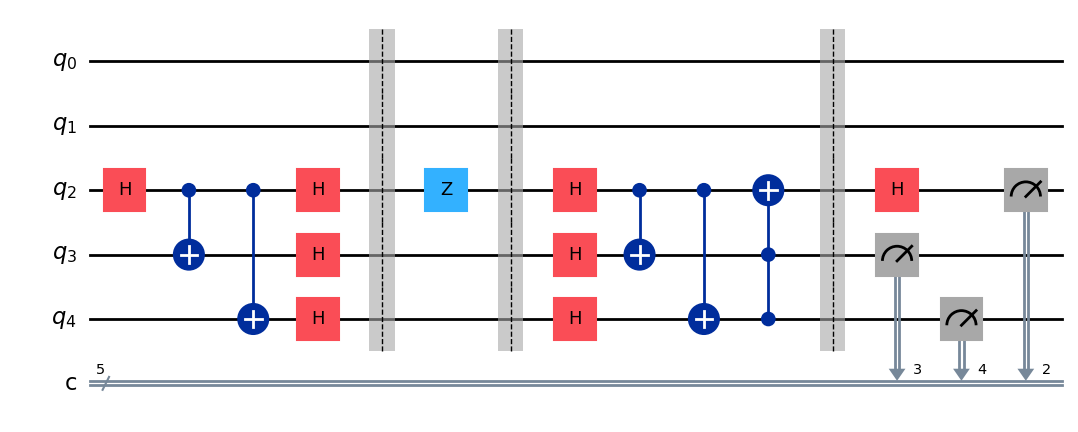

In [9]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Three qubit phase-flip error-correcting code
flip = QuantumCircuit(5, 5)

# In a similar way to the bit-flip error-correcting code, implement the phase-flip error-correcting code.
# Check that the code can correct a single phase flip but not two or more simultaneous phase flips.
# What happens if you introduce a bit flip?
# The next cell still has the simulation and measurement. Implement the phase flip code on the same qubits
# as for the bit flip code, so you can reuse the simulation and measurement.

# Prepare a state to protect (e.g. put qubit 0 in superposition)
flip.h(2)  # State to protect: |+>

# Encode — spread the state across 3 qubits using CNOT, then H on all
flip.cx(2, 3)
flip.cx(2, 4)
flip.h(2)
flip.h(3)
flip.h(4)
flip.barrier()

# Introduce an error — try each of these one at a time:
# Single phase flip on qubit 0
flip.z(2)

# Single phase flip on qubit 1
# phase_flip.z(3)

# Single phase flip on qubit 2
# phase_flip.z(4)

# Two phase flips
# phase_flip.z(2)
# phase_flip.z(3)

# Bit flip instead of phase flip
# phase_flip.x(2)

flip.barrier()

# Decode — apply H to all, then CNOT to correct
flip.h(2)
flip.h(3)
flip.h(4)
flip.cx(2, 3)
flip.cx(2, 4)

# Syndrome measurement and correction
# Use ancilla-free majority voting via Toffoli gate
flip.ccx(3, 4, 2)  # Correct qubit 0 based on qubits 1 and 2
flip.barrier()

# Undo the initial H to return to computational basis for measurement
flip.h(2)
flip.measure([2, 3, 4], [2, 3, 4])
flip.draw("mpl")

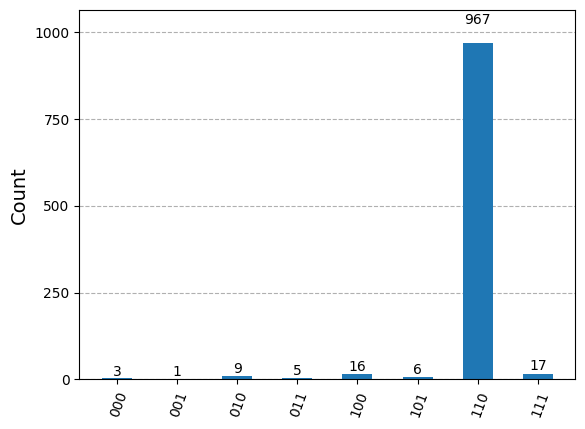

In [10]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=5, control_flow=True)
compiled = transpile(flip, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts,indices=[2,3,4])
plot_histogram(mcounts)